# Shiftr: master schedule generator (core process)

> **Synthetic data.** The restaurant, staff, bookings and history are invented for the MSIN0023 prototype.

This notebook builds the October 2026 master schedule for every employee. It covers:
- who works, on which day and at what time
- **where in the restaurant** each person is placed
- each person's **break**

**Team rules from `Team_Project_Context`:**
1. **Always meet at least the demand from confirmed future bookings.**
2. Use October 2025 history to project the **extra demand from walk-ins** (dining room and bar).

**Pipeline:** each step is a plain function in `shiftr_core.py`, so it can be tested on its own.

| Step | Function | What it does |
|---|---|---|
| 1 | `load_staff`, `load_availability` | Who can work, when, at what wage |
| 2 | `load_bookings` | Confirmed covers per booking and arrival time. This is the **minimum** demand |
| 3 | `load_walkin_history` | Average walk-ins per weekday from Oct 2025. This is the **extra** demand |
| 4 | `build_demand` | Guests in the building in every half-hour slot |
| 5 | `build_requirements` | Staff needed per station per slot, in two tiers: bookings only, and bookings plus walk-ins |
| 6 | `build_schedule` | Integer programme (PuLP) that finds the cheapest rota obeying availability and UK Working Time Regulations |
| 7 | `validate_schedule`, `export_excel` | Independent checks, then an Excel output |

Run the cells from top to bottom. Step 6 takes about 2 minutes.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import shiftr_core as sc

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

DATA = Path("data")
STAFF_FILE = DATA / "Shiftr_Staff_Availability_Oct2026.xlsx"
BOOKINGS_FILE = DATA / "Shiftr_October_2026_Synthetic_Bookings.xlsx"
HISTORY_FILE = DATA / "Shiftr_October_2025_Historical_Demand.xlsx"
OUTPUT_FILE = Path("outputs") / "Shiftr_Master_Schedule_Oct2026.xlsx"

for f in (STAFF_FILE, BOOKINGS_FILE, HISTORY_FILE):
    print(("OK      " if f.exists() else "MISSING ") + str(f))

Matplotlib is building the font cache; this may take a moment.


OK      data/Shiftr_Staff_Availability_Oct2026.xlsx
OK      data/Shiftr_October_2026_Synthetic_Bookings.xlsx
OK      data/Shiftr_October_2025_Historical_Demand.xlsx


## Step 1: Staff availability

- **`available`** is a **hard** rule: 1 means they can work that block (AM 10:00–16:00 or PM 16:00–00:30).
- **`preference`** is a **soft** rule: +1 preferred, −1 would rather not. The optimiser gives a small bonus or penalty but can override it.

In [2]:
staff = sc.load_staff(STAFF_FILE)
availability = sc.load_availability(STAFF_FILE)
dates = sorted(availability["date"].unique())

print(f"{len(staff)} staff, {len(availability)} availability rows, {dates[0]} to {dates[-1]}")
print(f"Available staff-blocks: {availability['available'].mean():.0%}")
staff.groupby(["role", "seniority"]).size().unstack(fill_value=0)

34 staff, 2108 availability rows, 2026-10-01 to 2026-10-31
Available staff-blocks: 71%


seniority,Junior,Senior
role,,
Bartender,4,1
Chef,5,3
Host,3,0
Kitchen Porter,4,0
Manager,0,3
Server,9,2


## Step 2: Future bookings (the minimum demand)

Cancelled and no-show bookings already have 0 covers in the file, so they're dropped.

In [3]:
bookings = sc.load_bookings(BOOKINGS_FILE)
print(f"{len(bookings)} bookings with covers, {bookings['covers'].sum()} covers in total")
daily_bookings = bookings.pivot_table(index="date", columns="meal", values="covers", aggfunc="sum", fill_value=0)
daily_bookings["Total"] = daily_bookings.sum(axis=1)
daily_bookings.head(10)

495 bookings with covers, 2040 covers in total


meal,Dinner,Lunch,Total
date,,,
2026-10-01,15,21,36
2026-10-02,92,33,125
2026-10-03,50,61,111
2026-10-04,36,24,60
2026-10-05,15,8,23
2026-10-06,18,10,28
2026-10-07,31,9,40
2026-10-08,30,9,39
2026-10-09,92,4,96


## Step 3: Historic walk-ins (the extra demand)

These are average walk-ins per weekday in October 2025. Each average is based on **only 4–5 days**, so treat it as a rough estimate.

In [4]:
walkin_means = sc.load_walkin_history(HISTORY_FILE)
walkin_means

,walkin_lunch,walkin_dinner,bar,days_observed
Day,,,,
Monday,6.5,8.2,17.2,4
Tuesday,9.0,5.5,18.5,4
Wednesday,6.2,9.2,13.2,5
Thursday,6.4,10.0,23.2,5
Friday,11.2,11.8,32.4,5
Saturday,10.2,14.8,39.5,4
Sunday,7.5,10.5,16.8,4


## Step 4: Guests in the building, per half-hour

**Bookings:** each booking stays for `DWELL_HOURS` (lunch 1.5 h, dinner 2 h).

**Walk-ins:** each day's average is spread over typical arrival times (`WALKIN_ARRIVALS`). Walk-ins can only take seats that bookings leave free, up to `SEATS` = 50.

**Overbooking check:** slots where bookings alone exceed 50 seats are flagged. Staffing is planned for at most 50 diners, so the manager must fix those bookings rather than add staff.

In [5]:
demand = sc.build_demand(bookings, walkin_means, dates, walkin_multiplier=1.0)

over = demand[demand["overbooked"]]
print(f"Slots where bookings exceed {sc.SEATS} seats: {len(over)} (days: {sorted({d.strftime('%a %d') for d in over['date']})})")
demand[demand["date"] == dates[1]].iloc[16:26]

Slots where bookings exceed 50 seats: 25 (days: ['Fri 02', 'Fri 09', 'Fri 23', 'Fri 30', 'Sat 24', 'Sat 31', 'Thu 15', 'Thu 29'])


,date,weekday,slot,time,booked_food,walkin_food,food_total,seated_for_staffing,bar,overbooked
45,2026-10-02,Fri,18.0,18:00,12.8,1.18,13.98,13.98,3.89,False
46,2026-10-02,Fri,18.5,18:30,23.0,2.95,25.95,25.95,3.89,False
47,2026-10-02,Fri,19.0,19:00,66.6,0.00,66.60,50.00,4.54,True
48,2026-10-02,Fri,19.5,19:30,63.0,0.00,63.00,50.00,4.54,True
49,2026-10-02,Fri,20.0,20:00,76.2,0.00,76.20,50.00,4.54,True
50,2026-10-02,Fri,20.5,20:30,69.0,0.00,69.00,50.00,4.54,True
51,2026-10-02,Fri,21.0,21:00,23.0,6.49,29.49,29.49,3.89,False
52,2026-10-02,Fri,21.5,21:30,23.0,4.13,27.13,27.13,3.89,False
53,2026-10-02,Fri,22.0,22:00,3.0,2.36,5.36,5.36,3.89,False
54,2026-10-02,Fri,22.5,22:30,0.0,1.18,1.18,1.18,3.89,False


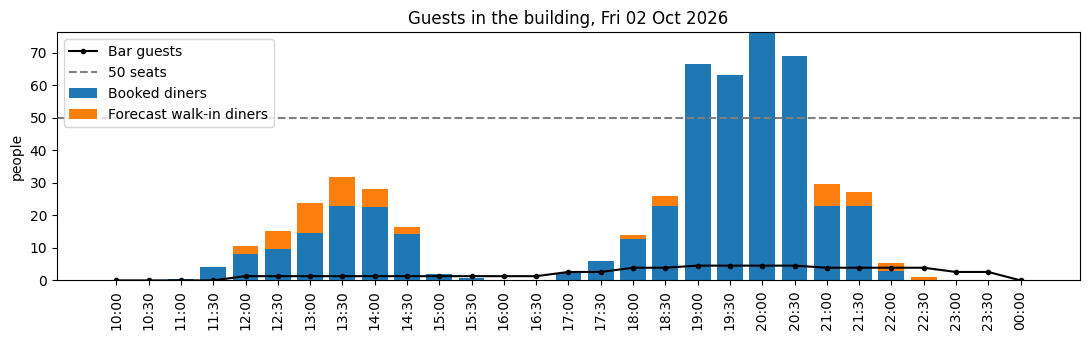

In [6]:
day = dates[1]   # Fri 2 Oct, a busy day with a corporate dinner
d = demand[demand["date"] == day]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(d["time"], d["booked_food"], label="Booked diners")
ax.bar(d["time"], d["walkin_food"], bottom=d["booked_food"], label="Forecast walk-in diners")
ax.plot(d["time"], d["bar"], color="black", marker=".", label="Bar guests")
ax.axhline(sc.SEATS, ls="--", color="grey", label=f"{sc.SEATS} seats")
ax.set_title(f"Guests in the building, {day:%a %d %b %Y}")
ax.set_ylabel("people")
ax.tick_params(axis="x", rotation=90)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 5: Staff needed per station

Each slot gets two requirements:
- **`req_min`** comes from **bookings only**. It also includes the fixed minimums: a duty manager, a senior chef on the pass, a kitchen porter, a bartender and a server whenever open. The optimiser must always meet it.
- **`req_full`** comes from **bookings plus forecast walk-ins**. It's met where staff allow, and any shortfall is reported.

**Productivity assumptions:** one line chef per 20 diners, one server per 12, one kitchen porter per 35, and so on. These are team assumptions set in `shiftr_core.py`.

### Hand check: the requirement rules

These expected values were worked out by hand, not taken from the code. Example: with 50 diners and 6 bar guests at 19:30, line chefs = ⌈50/20⌉ = 3, servers = ⌈50/12⌉ = 5, KPs = ⌈50/35⌉ = 2, bartenders = ⌈6/8 + 50/40⌉ = ⌈2.0⌉ = 2.

In [7]:
got = sc.station_requirements(food=50, bar=6, slot=19.5)
expected = {"Duty Manager (Floor)": 1, "Pass": 1, "Hot Line": 3, "Pizza Oven": 1,
            "Dish & Prep": 2, "Dining Room": 5, "Host Stand": 1, "Bar": 2}
assert got == expected, got
quiet = sc.station_requirements(food=0, bar=0, slot=10.0)   # 10:00 set-up, nobody in yet
assert quiet["Hot Line"] == 1 and quiet["Bar"] == 0 and quiet["Dining Room"] == 1, quiet
print("Requirement rules match the hand-calculated values.")

Requirement rules match the hand-calculated values.


In [8]:
requirements = sc.build_requirements(demand)
fri = requirements[requirements["date"] == day]
fri.pivot(index="station", columns="time", values="req_full").loc[:, "17:00":"22:00"]

time,17:00,17:30,18:00,18:30,19:00,19:30,20:00,20:30,21:00,21:30,22:00
station,,,,,,,,,,,
Bar,1,1,1,2,2,2,2,2,2,2,1
Dining Room,1,1,2,3,5,5,5,5,3,3,1
Dish & Prep,1,1,1,1,2,2,2,2,1,1,1
Duty Manager (Floor),1,1,1,1,1,1,1,1,1,1,1
Host Stand,0,0,0,1,1,1,1,1,1,1,0
Hot Line,1,1,1,2,3,3,3,3,2,2,1
Pass,1,1,1,1,1,1,1,1,1,1,1
Pizza Oven,0,0,1,1,1,1,1,1,1,1,0


## Step 6: Build the schedule (optimisation)

PuLP chooses who works which shift at which station. It **minimises**:
- base wages, plus
- a small penalty for disliked days and a small bonus for preferred shifts, plus
- a very large penalty for any staff shortfall against bookings, plus
- a moderate penalty for any shortfall against forecast walk-ins.

It must also respect these rules:

| Rule | Source |
|---|---|
| Only work a block you're available for | Staff availability sheet |
| One shift per person per day | Team rule |
| Weekly paid hours ≤ contract cap (all ≤ 48; students ≤ 20) | Working Time Regulations 1998; Student visa limit |
| At least 1 day off per week | Working Time Regulations 1998 |
| At least 11 h rest between shifts, so no 00:30 finish followed by a 10:00 or 11:00 start | Working Time Regulations 1998 |
| A shift over 6 h includes a 30-min unpaid break, **off the floor** | Working Time Regulations 1998 |
| Full-time staff are paid 35 h a week whether or not they're used | Team assumption |

**Shift patterns:**
- Day 10:00–16:00 and Lunch 11:00–15:00
- Dinner 17:00–23:00 and Late 19:00–00:30
- Evening 16:00–00:30, which has four break options. The optimiser puts each break where cover is still met.

**Stations:**
- Duty Manager (a senior waiter can also cover this)
- Host Stand and Dining Room
- Bar
- Pass (senior chefs only), Hot Line, Pizza Oven, Dish & Prep

**How it solves:** one week at a time, like a manager would. The 11-hour rest rule carries over from each Sunday into the next Monday.

In [9]:
schedule, info = sc.build_schedule(staff, availability, requirements, time_limit=45)
print("Status:", info["status"])
print("Shifts scheduled:", len(schedule))
info["weeks"]

Status: Some weeks stopped at the time limit (see weeks table)
Shifts scheduled: 637


,week,status,variables,seconds
0,01 Oct-04 Oct,Optimal,1160,2.3
1,05 Oct-11 Oct,Optimal,2024,13.0
2,12 Oct-18 Oct,"Feasible (time limit, may not be cheapest)",1988,45.0
3,19 Oct-25 Oct,"Feasible (time limit, may not be cheapest)",1866,45.0
4,26 Oct-31 Oct,Optimal,1670,2.9


## Step 7: The master schedule

Each row is one shift: employee, day, start and end time, area, placement and break.

In [10]:
cols = ["date", "day", "employee", "job_title", "area", "placement", "start", "end", "break", "paid_hours", "shift_cost_gbp"]
schedule[cols].head(25)

,date,day,employee,job_title,area,placement,start,end,break,paid_hours,shift_cost_gbp
0,2026-10-01,Thu,Nadia,Bartender,Bar,Bar,10:00,16:00,None (shift is 6 h or less),6.0,87.00
1,2026-10-01,Thu,Francesca,Waiter,Front of House,Dining Room - Section A,10:00,16:00,None (shift is 6 h or less),6.0,84.00
2,2026-10-01,Thu,Tomasz,Assistant Manager,Front of House,Duty Manager (Floor),10:00,16:00,None (shift is 6 h or less),6.0,111.00
3,2026-10-01,Thu,Tariq,Kitchen Porter,Kitchen,Dish & Prep,10:00,16:00,None (shift is 6 h or less),6.0,83.10
4,2026-10-01,Thu,Jun,Commis Chef,Kitchen,Hot Line,10:00,16:00,None (shift is 6 h or less),6.0,84.00
5,2026-10-01,Thu,Leila,Sous Chef,Kitchen,Pass,10:00,16:00,None (shift is 6 h or less),6.0,111.00
6,2026-10-01,Thu,Mia,Waiter,Front of House,Dining Room - Section B,11:00,15:00,None (shift is 6 h or less),4.0,56.00
7,2026-10-01,Thu,Sofia,Pizza Chef,Kitchen,Pizza Oven,11:00,15:00,None (shift is 6 h or less),4.0,60.00
8,2026-10-01,Thu,Ravi,Bartender,Bar,Bar,16:00,00:30,22:30-23:00 (unpaid),8.0,116.00
9,2026-10-01,Thu,Noah,Waiter,Front of House,Dining Room - Section C,16:00,00:30,22:30-23:00 (unpaid),8.0,108.00


In [11]:
# One person's month. Change the name to look at someone else.
schedule.loc[schedule["employee"] == "Leila", cols]

,date,day,employee,job_title,area,placement,start,end,break,paid_hours,shift_cost_gbp
5,2026-10-01,Thu,Leila,Sous Chef,Kitchen,Pass,10:00,16:00,None (shift is 6 h or less),6.0,111.00
33,2026-10-02,Fri,Leila,Sous Chef,Kitchen,Pass,16:00,00:30,23:00-23:30 (unpaid),8.0,148.00
61,2026-10-03,Sat,Leila,Sous Chef,Kitchen,Pass,16:00,00:30,23:00-23:30 (unpaid),8.0,148.00
96,2026-10-05,Mon,Leila,Sous Chef,Kitchen,Pass,10:00,16:00,None (shift is 6 h or less),6.0,111.00
113,2026-10-06,Tue,Leila,Sous Chef,Kitchen,Pass,10:00,16:00,None (shift is 6 h or less),6.0,111.00
139,2026-10-07,Wed,Leila,Sous Chef,Kitchen,Hot Line,19:00,00:30,None (shift is 6 h or less),5.5,101.75
154,2026-10-08,Thu,Leila,Sous Chef,Kitchen,Pizza Oven,17:00,23:00,None (shift is 6 h or less),6.0,111.00
164,2026-10-09,Fri,Leila,Sous Chef,Kitchen,Pass,10:00,16:00,None (shift is 6 h or less),6.0,111.00
202,2026-10-10,Sat,Leila,Sous Chef,Kitchen,Pizza Oven,17:00,23:00,None (shift is 6 h or less),6.0,111.00
238,2026-10-12,Mon,Leila,Sous Chef,Kitchen,Hot Line,16:00,00:30,23:00-23:30 (unpaid),8.0,148.00


In [12]:
# Rota grid, first full week (Mon 5 - Sun 11 Oct). OFF = not scheduled.
grid = sc.rota_grid(schedule)
week_cols = [c for c in grid.columns if c.endswith("Oct") and 5 <= int(c[4:6]) <= 11]
grid[["employee", "job_title"] + week_cols]

,employee,job_title,Mon 05 Oct,Tue 06 Oct,Wed 07 Oct,Thu 08 Oct,Fri 09 Oct,Sat 10 Oct,Sun 11 Oct
0,Amara,General Manager,OFF,19:00-00:30 Duty Manager (Floor),16:00-00:30 Duty Manager (Floor),19:00-00:30 Duty Manager (Floor),16:00-00:30 Duty Manager (Floor),16:00-00:30 Duty Manager (Floor),OFF
1,Tomasz,Assistant Manager,16:00-00:30 Duty Manager (Floor),16:00-00:30 Duty Manager (Floor),OFF,10:00-16:00 Duty Manager (Floor),OFF,19:00-00:30 Duty Manager (Floor),16:00-00:30 Duty Manager (Floor)
2,Priya,Floor Supervisor,OFF,OFF,OFF,OFF,OFF,OFF,OFF
3,Marco,Head Chef,OFF,OFF,10:00-16:00 Pass,10:00-16:00 Pass,16:00-00:30 Pass,16:00-00:30 Pass,16:00-00:30 Pass
4,Leila,Sous Chef,10:00-16:00 Pass,10:00-16:00 Pass,19:00-00:30 Hot Line,17:00-23:00 Pizza Oven,10:00-16:00 Pass,17:00-23:00 Pizza Oven,OFF
5,Giulia,Senior Chef de Partie,16:00-00:30 Pass,16:00-00:30 Pass,16:00-00:30 Pass,16:00-00:30 Pass,OFF,10:00-16:00 Pass,10:00-16:00 Pass
6,Daniel,Chef de Partie,17:00-23:00 Pizza Oven,10:00-16:00 Hot Line,16:00-00:30 Hot Line,OFF,10:00-16:00 Hot Line,10:00-16:00 Hot Line,10:00-16:00 Hot Line
7,Sofia,Pizza Chef,OFF,16:00-00:30 Hot Line,OFF,19:00-00:30 Hot Line,16:00-00:30 Hot Line,16:00-00:30 Hot Line,16:00-00:30 Hot Line
8,Kwame,Commis Chef,OFF,OFF,19:00-00:30 Pizza Oven,16:00-00:30 Hot Line,17:00-23:00 Pizza Oven,17:00-23:00 Hot Line,11:00-15:00 Pizza Oven
9,Jun,Commis Chef,10:00-16:00 Hot Line,OFF,10:00-16:00 Hot Line,10:00-16:00 Hot Line,OFF,OFF,19:00-00:30 Hot Line


## Step 8: Check the schedule

The checks below recompute every rule directly from the finished schedule, **independently of the solver**.

If the last check fails, the current staff list can't cover the confirmed bookings. The **extra cover needed** table then shows exactly which posts need cover from agency staff, overtime or a booking change.

In [13]:
coverage = sc.coverage_report(schedule, requirements)
checks = sc.validate_schedule(schedule, staff, availability, coverage)
print(f"Coverage score (bookings + forecast walk-ins): {sc.coverage_score(coverage):.1%}")
checks

Coverage score (bookings + forecast walk-ins): 97.1%


,check,violations,result
0,Nobody works a block they are unavailable for,0,PASS
1,At most one shift per person per day,0,PASS
2,Weekly paid hours within each contract cap (al...,0,PASS
3,At least one day off in every week,0,PASS
4,At least 11 h rest between shifts,0,PASS
5,Every shift over 6 h includes a break,0,PASS
6,Everyone is placed at a station their role all...,0,PASS
7,All wages >= National Living Wage (GBP 12.71),0,PASS
8,Demand from confirmed BOOKINGS fully staffed (...,110,FAIL


In [14]:
extra = sc.extra_cover_needed(coverage, "short_vs_bookings")
print(f"Extra cover needed to serve confirmed bookings: {extra['staff_hours'].sum():.1f} staff-hours "
      f"across {extra['date'].nunique()} days")
extra

Extra cover needed to serve confirmed bookings: 55.0 staff-hours across 17 days


,date,day,station,from,to,extra_staff,staff_hours
0,2026-10-02,Fri,Hot Line,13:30,14:30,1,1.0
1,2026-10-02,Fri,Hot Line,18:30,19:00,1,0.5
2,2026-10-02,Fri,Hot Line,19:00,21:00,2,4.0
3,2026-10-02,Fri,Hot Line,21:00,22:00,1,1.0
4,2026-10-02,Fri,Pizza Oven,13:00,15:00,1,2.0
5,2026-10-03,Sat,Dish & Prep,17:00,17:30,1,0.5
6,2026-10-03,Sat,Hot Line,13:30,15:00,1,1.5
7,2026-10-06,Tue,Dish & Prep,22:30,23:00,1,0.5
8,2026-10-09,Fri,Hot Line,18:30,21:00,2,5.0
9,2026-10-09,Fri,Hot Line,21:00,22:00,1,1.0


## Step 9: Labour cost

The figures below are base pay only, **excluding tronc and tips**. Wages are central-London estimates.

In [15]:
print(f"Total labour cost, October 2026: £{schedule['shift_cost_gbp'].sum():,.0f} for {schedule['paid_hours'].sum():,.0f} paid hours")
by_area = schedule.groupby("area")[["paid_hours", "shift_cost_gbp"]].sum().round(0)
by_area

Total labour cost, October 2026: £62,451 for 4,051 paid hours


,paid_hours,shift_cost_gbp
area,,
Bar,614.0,9068.0
Front of House,1688.0,26178.0
Kitchen,1749.0,27205.0


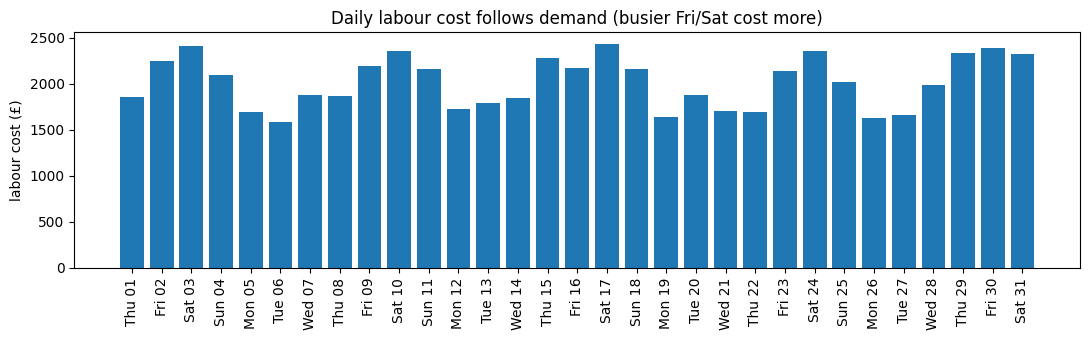

In [16]:
cost_by_day = schedule.groupby("date")["shift_cost_gbp"].sum()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar([d.strftime("%a %d") for d in cost_by_day.index], cost_by_day.values)
ax.set_ylabel("labour cost (£)")
ax.set_title("Daily labour cost follows demand (busier Fri/Sat cost more)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Step 10: Export to Excel

The workbook has these sheets: Summary, Master_Schedule, Rota_Grid, Staff_Hours, Demand_by_Slot, Coverage, Shortfalls, Extra_Cover_Needed, Validation and Solver_Weeks.

In [17]:
path = sc.export_excel(OUTPUT_FILE, schedule, grid, demand, coverage, checks, staff, info, extra)
print("Saved", path)

Saved outputs/Shiftr_Master_Schedule_Oct2026.xlsx


## Optional: what-if

Change one assumption and re-run Steps 4–9, then compare cost and cover. For example:
- `walkin_multiplier=1.3` for 30% more walk-ins (a sunny half-term week)
- remove a person to model illness: `availability.loc[availability["staff_id"] == "S05", "available"] = 0`
- change `sc.COVERS_PER_SERVER` or another productivity assumption

The cell below re-solves the whole month and takes about 2 minutes, so it's commented out.

In [18]:
# demand_wi = sc.build_demand(bookings, walkin_means, dates, walkin_multiplier=1.3)
# req_wi = sc.build_requirements(demand_wi)
# sched_wi, info_wi = sc.build_schedule(staff, availability, req_wi)
# print(f"Cost: £{schedule['shift_cost_gbp'].sum():,.0f} -> £{sched_wi['shift_cost_gbp'].sum():,.0f}")

## Limitations: be explicit about these in the video and deck

- **Synthetic data:** all inputs are invented. Results show that the method works, not real savings.
- **Assumptions:** dwell times, walk-in arrival times and productivity ratios are team assumptions, not measured values.
- **Thin history:** the walk-in forecast is an average of only 4–5 past days per weekday. There's no trend, weather or event adjustment beyond the bookings themselves.
- **Fixed shifts:** shifts are fixed patterns inside the AM/PM availability blocks. Split shifts aren't modelled.
- **Week by week:** each week is solved separately. Weeks that hit the 45-second time limit are labelled and may not be the very cheapest rota.
- **Labelled sections:** dining-room sections (A, B, C…) are labels for placement, not a seating plan.
- **No baseline yet:** there isn't a baseline comparison here yet. Comparing with a flat "same staff every hour" rota is the next step for the savings claim.

## Run in ManSci Lab

1. Copy the `shiftr` folder to **My Work**.
2. Open this notebook from inside `shiftr`.
3. Choose **Run → Run All Cells**.

It uses only packages already installed on the VM: `pandas`, `pulp`, `openpyxl` and `matplotlib`. `shiftr_core.py` must sit in the same folder as the notebook.

**Terminal equivalent (optional):** `cd` changes into the project folder. Then run the notebook non-interactively:

```
cd shiftr
jupyter nbconvert --to notebook --execute Shiftr_Master_Schedule.ipynb
```